In [ ]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



# **DATA INFORMATION**

In [7]:

df=pd.read_csv("D:\DATA_Science\HEART ATTACK ML\data\Raw\heart_attack_dataset.csv")
df.head()

,patient_id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,...,num_major_vessels,thalassemia,bmi,smoking_status,alcohol_consumption,physical_activity,family_history,diabetes,stress_level,heart_attack_risk
0,1,59,Male,Asymptomatic,105.0,154.0,0.0,ST-T Abnormality,186.0,1,...,1,Fixed Defect,23.5,Former,Heavy,Moderate,1,1,6.0,0
1,2,50,Male,Non-anginal Pain,102.0,180.0,0.0,Normal,183.0,0,...,0,Reversible Defect,19.3,NaN,Moderate,High,0,0,8.0,0
2,3,61,Male,Atypical Angina,117.0,213.0,1.0,Normal,161.0,0,...,1,Fixed Defect,30.5,Never,Moderate,Low,1,1,2.0,1
3,4,73,Female,Atypical Angina,121.0,208.0,1.0,Normal,150.0,0,...,0,Normal,28.6,Former,Moderate,Moderate,0,0,4.0,0
4,5,49,Male,Non-anginal Pain,106.0,157.0,0.0,Normal,185.0,0,...,0,Reversible Defect,21.4,Former,Moderate,Moderate,0,0,NaN,0


In [10]:
df.shape

(7000, 22)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient_id           7000 non-null   int64  
 1   age                  7000 non-null   int64  
 2   gender               7000 non-null   str    
 3   chest_pain_type      7000 non-null   str    
 4   resting_bp           6720 non-null   float64
 5   cholesterol          6602 non-null   float64
 6   fasting_blood_sugar  6804 non-null   float64
 7   resting_ecg          6801 non-null   str    
 8   max_heart_rate       6721 non-null   float64
 9   exercise_angina      7000 non-null   int64  
 10  oldpeak              6650 non-null   float64
 11  st_slope             7000 non-null   str    
 12  num_major_vessels    7000 non-null   int64  
 13  thalassemia          7000 non-null   str    
 14  bmi                  6670 non-null   float64
 15  smoking_status       6495 non-null   str    
 16 

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,7000.0,3500.500000,2020.870275,1.0,1750.75,3500.5,5250.250,7000.0
age,7000.0,51.919857,13.891205,18.0,43.00,52.0,61.000,90.0
resting_bp,6720.0,116.447917,13.197267,80.0,107.00,116.0,125.000,162.0
cholesterol,6602.0,184.647683,33.180086,100.0,162.00,184.0,207.000,316.0
fasting_blood_sugar,6804.0,0.252939,0.434728,0.0,0.00,0.0,1.000,1.0
max_heart_rate,6721.0,173.942717,15.125315,115.0,164.00,174.0,184.000,210.0
exercise_angina,7000.0,0.323714,0.467926,0.0,0.00,0.0,1.000,1.0
oldpeak,6650.0,1.274496,1.055225,0.0,0.50,1.0,1.700,6.5
num_major_vessels,7000.0,0.749143,0.985500,0.0,0.00,0.0,1.000,3.0
bmi,6670.0,27.113358,5.006409,15.0,23.70,27.1,30.575,49.4


In [17]:
df.isna().sum()

patient_id               0
age                      0
gender                   0
chest_pain_type          0
resting_bp             280
cholesterol            398
fasting_blood_sugar    196
resting_ecg            199
max_heart_rate         279
exercise_angina          0
oldpeak                350
st_slope                 0
num_major_vessels        0
thalassemia              0
bmi                    330
smoking_status         505
alcohol_consumption    405
physical_activity      346
family_history           0
diabetes                 0
stress_level           268
heart_attack_risk        0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

# **Exploratory Data Analysis (EDA)**

heart_attack_risk
0    4060
1    2940
Name: count, dtype: int64


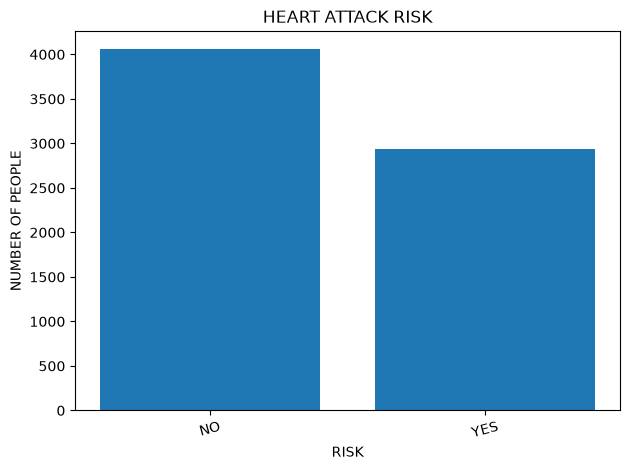

In [23]:
Data=(df["heart_attack_risk"].value_counts())
print(Data)
plt.bar(Data.index, Data.values)
plt.title("HEART ATTACK RISK") #judulbesar
plt.xlabel("RISK")             #judul x axis
plt.ylabel("NUMBER OF PEOPLE")  #judul y axis
plt.xticks([0, 1], ['NO', 'YES'])
plt.xticks(rotation=15)     # biar nama var x itu miring 
plt.tight_layout()  # ngerapiin otomatis
plt.show()

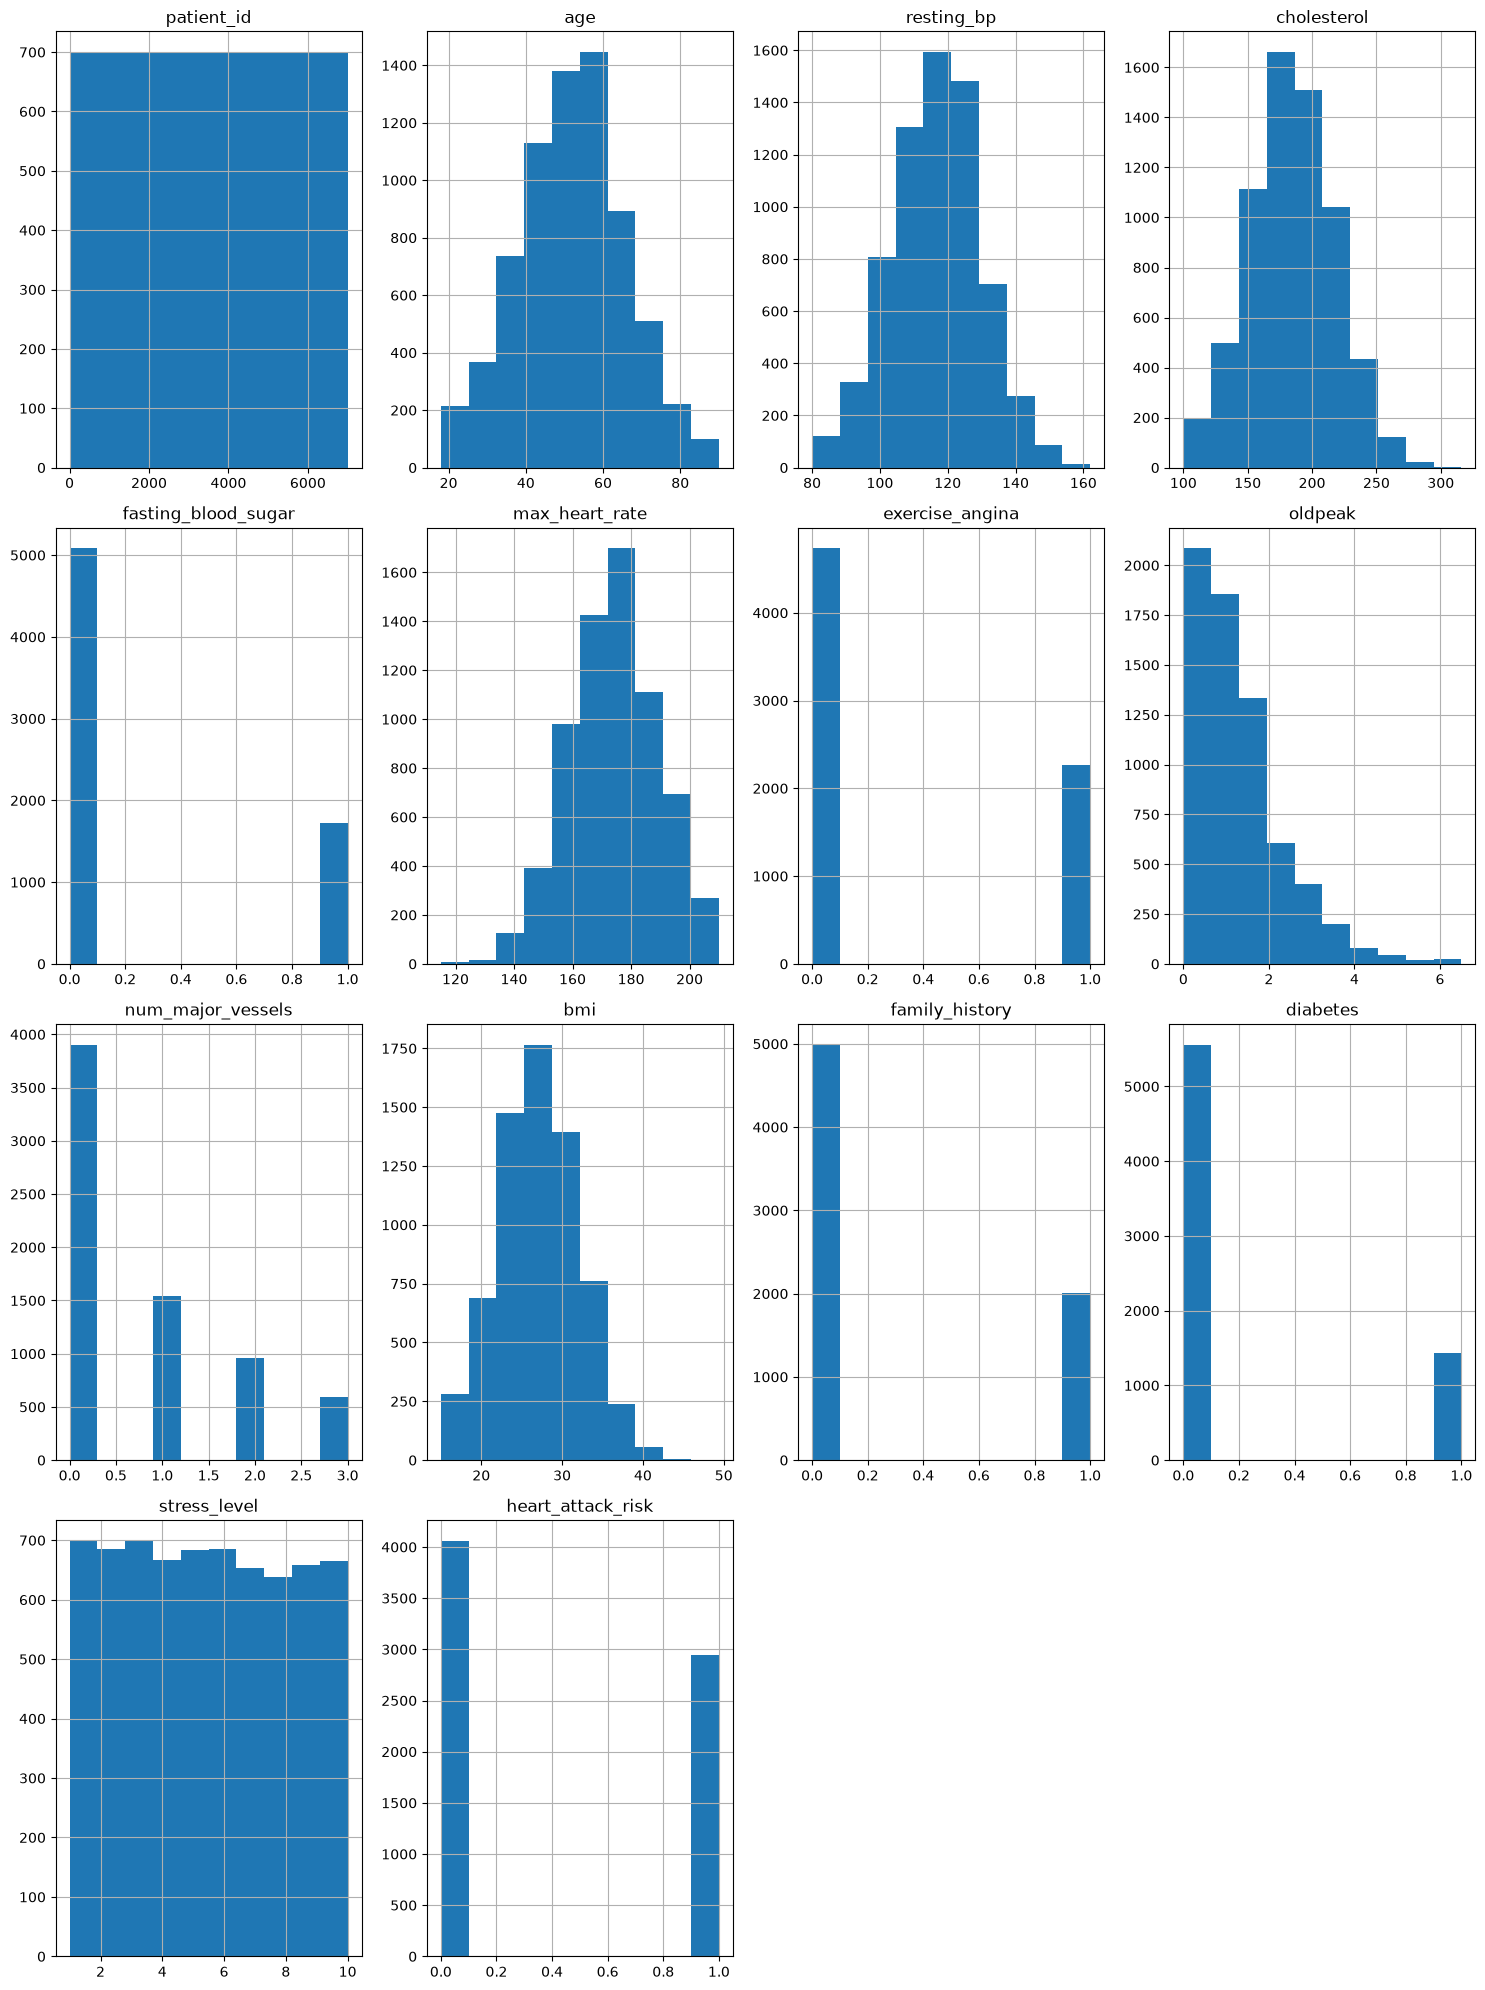

In [25]:
df.hist(figsize=(15,20))
plt.tight_layout()
plt.show()

SKEWED

NORMAL SKEW :
-AGE
-resting_bp
-cholesterol
-bmi

POSITIVE SKEW :
-oldpeak

NEGATIVE SKEW :
-max_heart_rate (slightly)

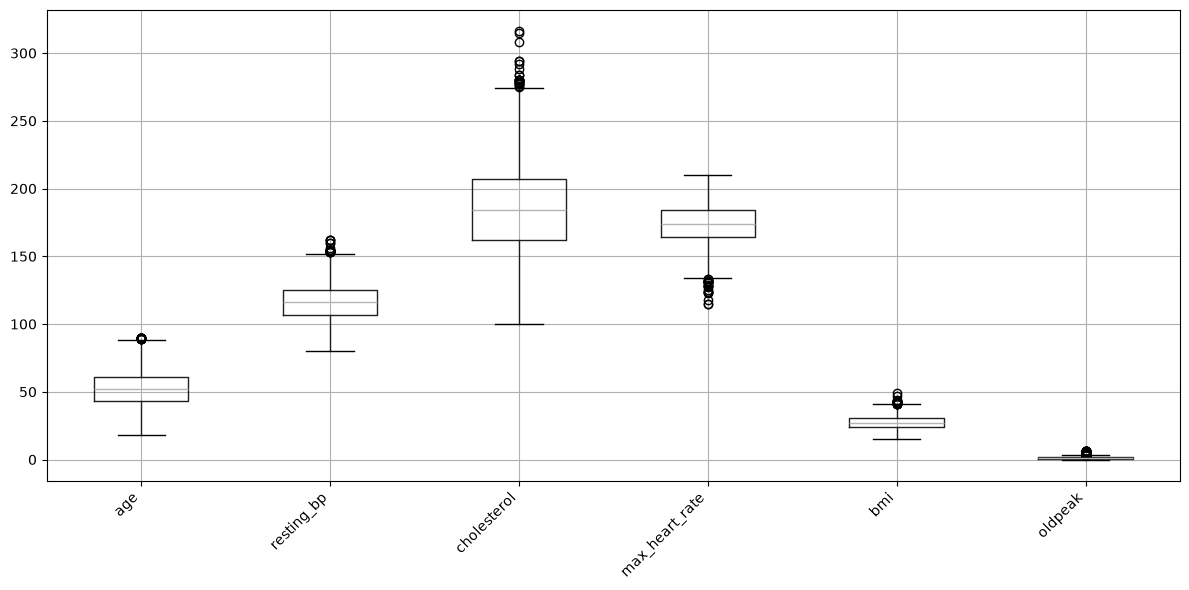

In [30]:

plt.figure(figsize=(12, 6))
df[["age", "resting_bp", "cholesterol", "max_heart_rate", "bmi", "oldpeak"]].boxplot()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

OUTLIER

SIGNIFICANT OUTLIER :
-cholesterol (300+)
-resting_bp  (155+)

NORMAL OUTLIER:
-age
-max_heart_rate
-bmi
-oldpeak

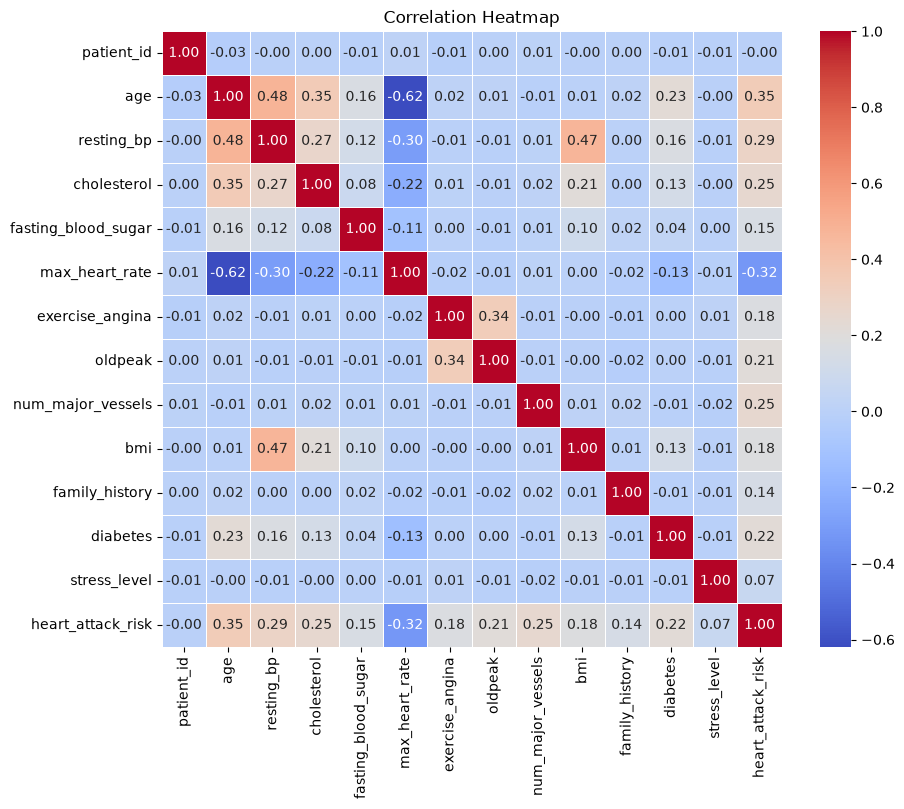

In [31]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8)) 
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
df= df.drop(columns = "stress_level") 
plt.title('Correlation Heatmap')
plt.show()

Correlation Insights from Heart Attack Dataset

Feature correlation to target (heart_attack_risk):

The most influential features for heart attack risk are age (0.35), max_heart_rate (-0.32), resting_bp (0.29), cholesterol and num_major_vessels (0.25), diabetes (0.22), and oldpeak (0.21). All of these features show a meaningful relationship with the target variable.
In terms of direction: higher age, higher blood pressure, higher cholesterol, more major vessels involved, and the presence of diabetes — all increase the risk of heart attack. Conversely, a higher max_heart_rate indicates a healthier heart condition (negative correlation of -0.32).

Multicollinearity between features:

No dangerous multicollinearity (>0.8) was found in this dataset. The highest inter-feature correlation is between age and max_heart_rate (-0.62), followed by age with resting_bp (0.48) and age with bmi (0.47). These relationships are medically expected — as age increases, many health indicators naturally change together.
Since all inter-feature correlations remain below the 0.8 threshold, all features can be retained for modeling without the need to drop or combine any of them.

In [33]:
from itertools import groupby


print(df.groupby("heart_attack_risk")["age"].mean())
print(df.groupby("heart_attack_risk")["resting_bp"].mean())
print(df.groupby("heart_attack_risk")["cholesterol"].mean())
print(df.groupby("heart_attack_risk")["max_heart_rate"].mean())
print(df.groupby("heart_attack_risk")["num_major_vessels"].mean())
print(df.groupby("heart_attack_risk")["diabetes"].mean())
print(df.groupby("heart_attack_risk")["oldpeak"].mean())

heart_attack_risk
0    47.826355
1    57.572789
Name: age, dtype: float64
heart_attack_risk
0    113.234615
1    120.891844
Name: resting_bp, dtype: float64
heart_attack_risk
0    177.602815
1    194.423870
Name: cholesterol, dtype: float64
heart_attack_risk
0    178.110598
1    168.191218
Name: max_heart_rate, dtype: float64
heart_attack_risk
0    0.540148
1    1.037755
Name: num_major_vessels, dtype: float64
heart_attack_risk
0    0.130788
1    0.309184
Name: diabetes, dtype: float64
heart_attack_risk
0    1.084591
1    1.536422
Name: oldpeak, dtype: float64
